In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

Device: cuda
Train images: 4429  patients: 2433
Val images:   803    patients: 428
Test images:  624   patients: 427
Class weights (sqrt): [1.2588625 0.7411375]
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 147MB/s] 


Starting training (full budget, EMA weights, cosine LR)
Epoch 01/100  Train L=0.3463 A=0.8654  Val L=0.6407 A=0.7347  LRs=1.00e-05/5.00e-05/1.00e-04
  best EMA model updated
Epoch 02/100  Train L=0.1347 A=0.9519  Val L=0.5633 A=0.7497  LRs=9.99e-06/5.00e-05/9.99e-05
  best EMA model updated
Epoch 03/100  Train L=0.1136 A=0.9634  Val L=0.4860 A=0.7522  LRs=9.98e-06/4.99e-05/9.98e-05
  best EMA model updated
Epoch 04/100  Train L=0.0852 A=0.9706  Val L=0.4164 A=0.7609  LRs=9.96e-06/4.98e-05/9.96e-05
  best EMA model updated
Epoch 05/100  Train L=0.0786 A=0.9729  Val L=0.3607 A=0.7883  LRs=9.94e-06/4.97e-05/9.94e-05
  best EMA model updated
Epoch 06/100  Train L=0.0744 A=0.9734  Val L=0.3116 A=0.8232  LRs=9.91e-06/4.96e-05/9.91e-05
  best EMA model updated
Epoch 07/100  Train L=0.0634 A=0.9765  Val L=0.2698 A=0.8593  LRs=9.88e-06/4.94e-05/9.88e-05
  best EMA model updated
Epoch 08/100  Train L=0.0632 A=0.9806  Val L=0.2295 A=0.8929  LRs=9.84e-06/4.92e-05/9.84e-05
  best EMA model updated


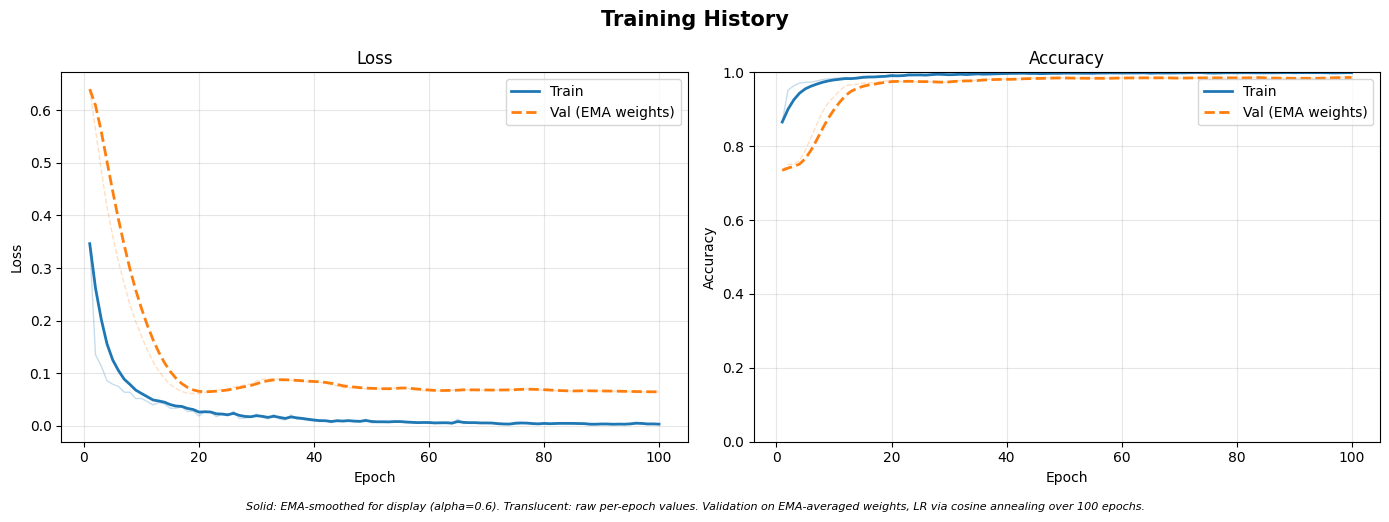


FINAL EVALUATION ON ALL DATASETS

Training Set - Loss: 0.0418, Accuracy: 0.9874
Validation Set - Loss: 0.0608, Accuracy: 0.9776
Test Set - Loss: 0.3398, Accuracy: 0.9022

Chosen threshold (>=95% sensitivity on val): 0.8014
TRAIN SET  default threshold 0.5000
  accuracy: 0.9874
  sensitivity: 0.9967
  specificity: 0.9605
  precision: 0.9865
  f1: 0.9915
  auc: 0.9989
              precision    recall  f1-score   support

      NORMAL       0.99      0.96      0.98      1140
   PNEUMONIA       0.99      1.00      0.99      3289

    accuracy                           0.99      4429
   macro avg       0.99      0.98      0.98      4429
weighted avg       0.99      0.99      0.99      4429

VALIDATION SET  default threshold 0.5000
  accuracy: 0.9776
  sensitivity: 0.9781
  specificity: 0.9761
  precision: 0.9915
  f1: 0.9847
  auc: 0.9978
              precision    recall  f1-score   support

      NORMAL       0.94      0.98      0.96       209
   PNEUMONIA       0.99      0.98      0.98

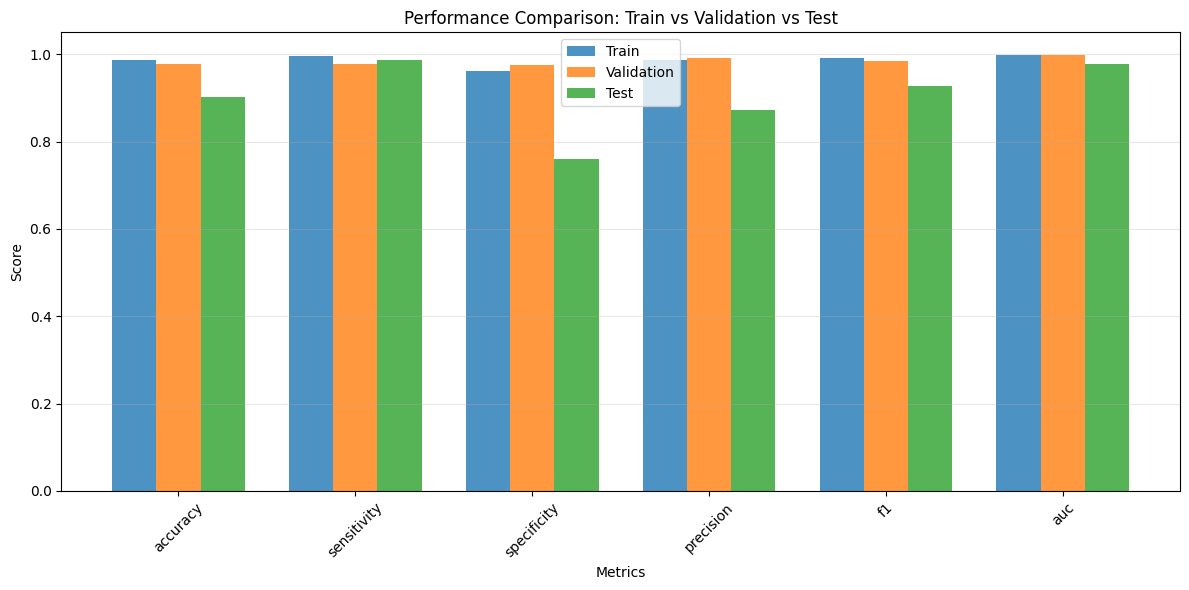

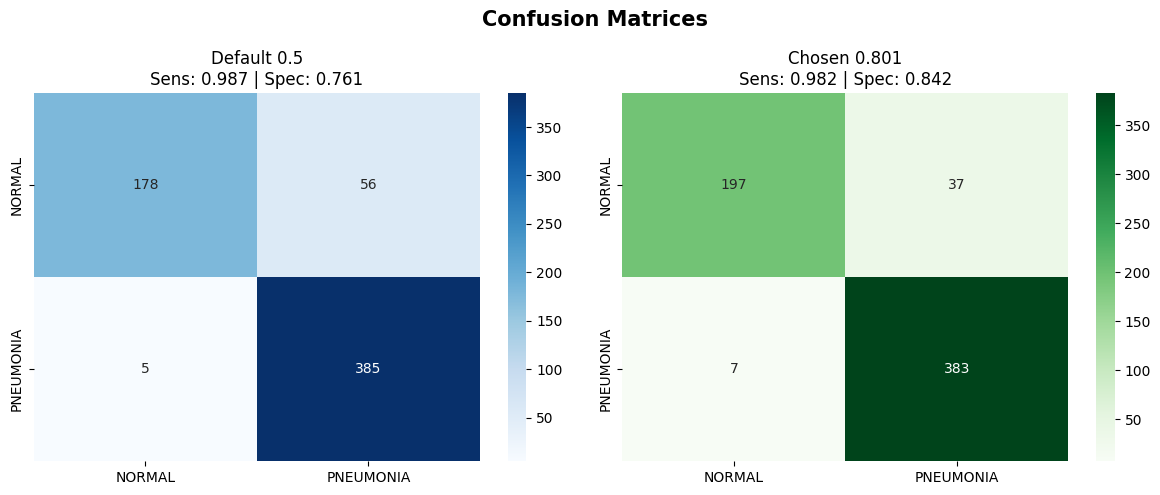

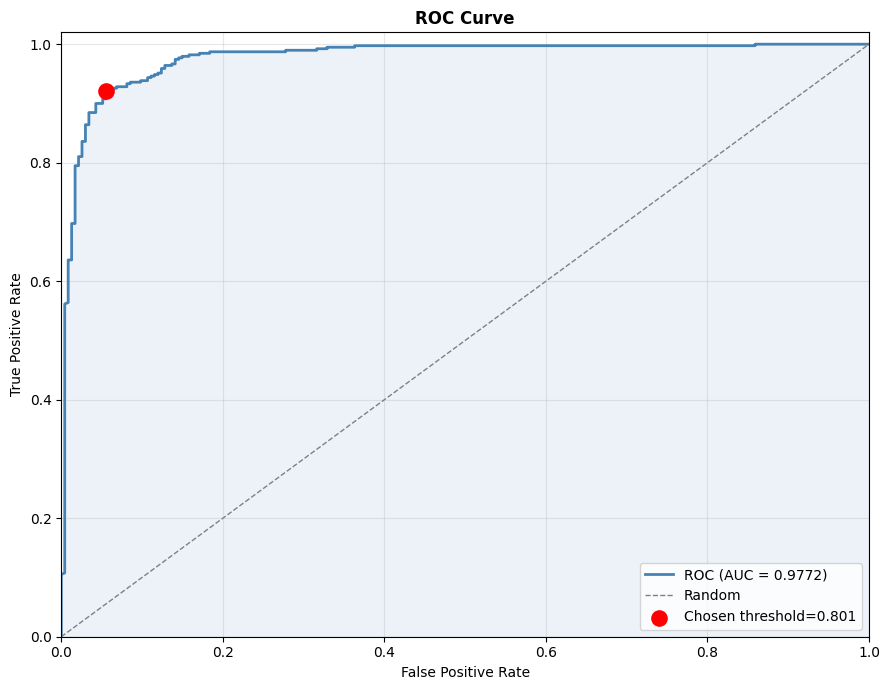

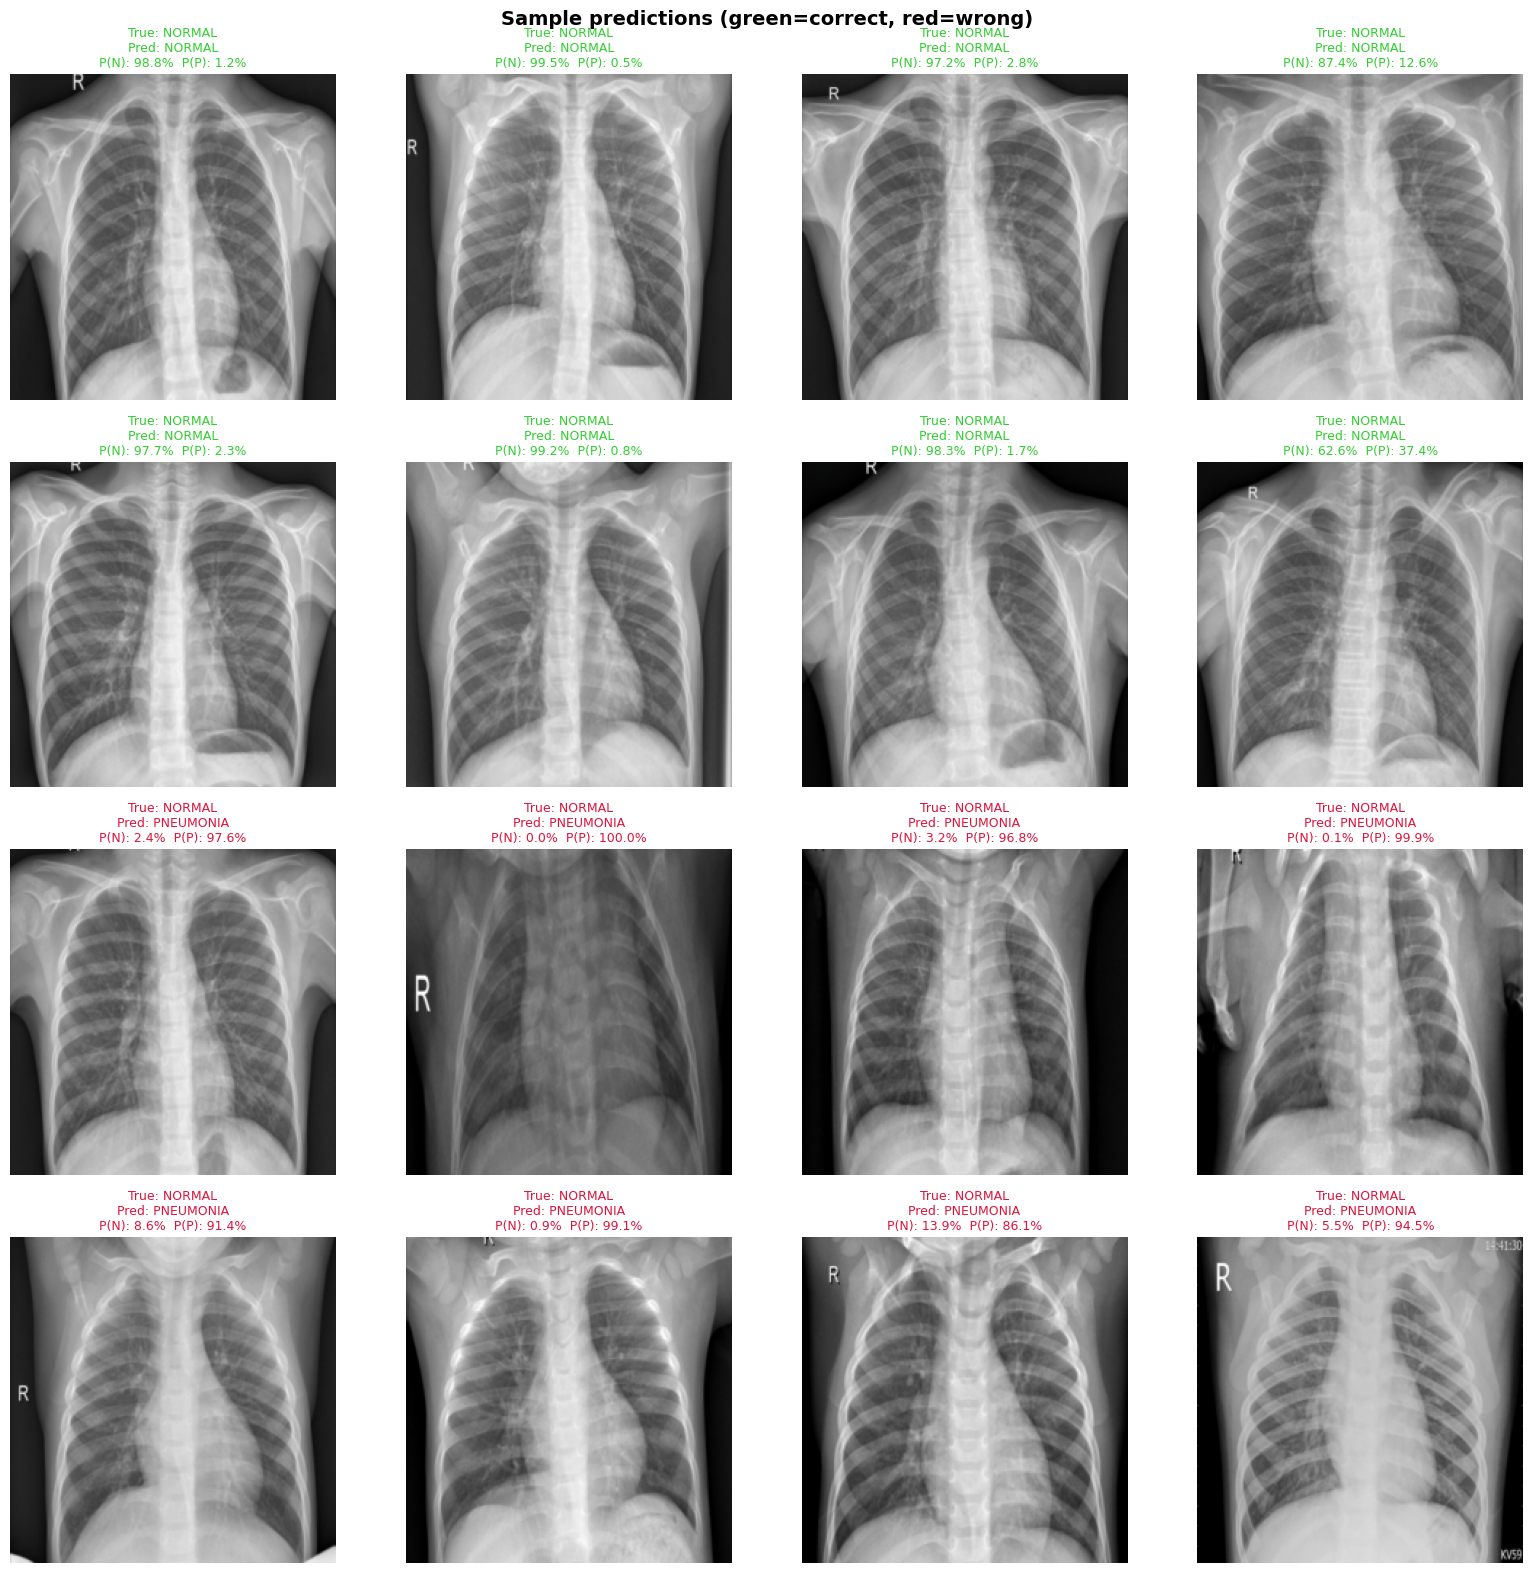


Generating Grad-CAM visualizations...


IndexError: Dimension out of range (expected to be in range of [-1, 0], but got 2)

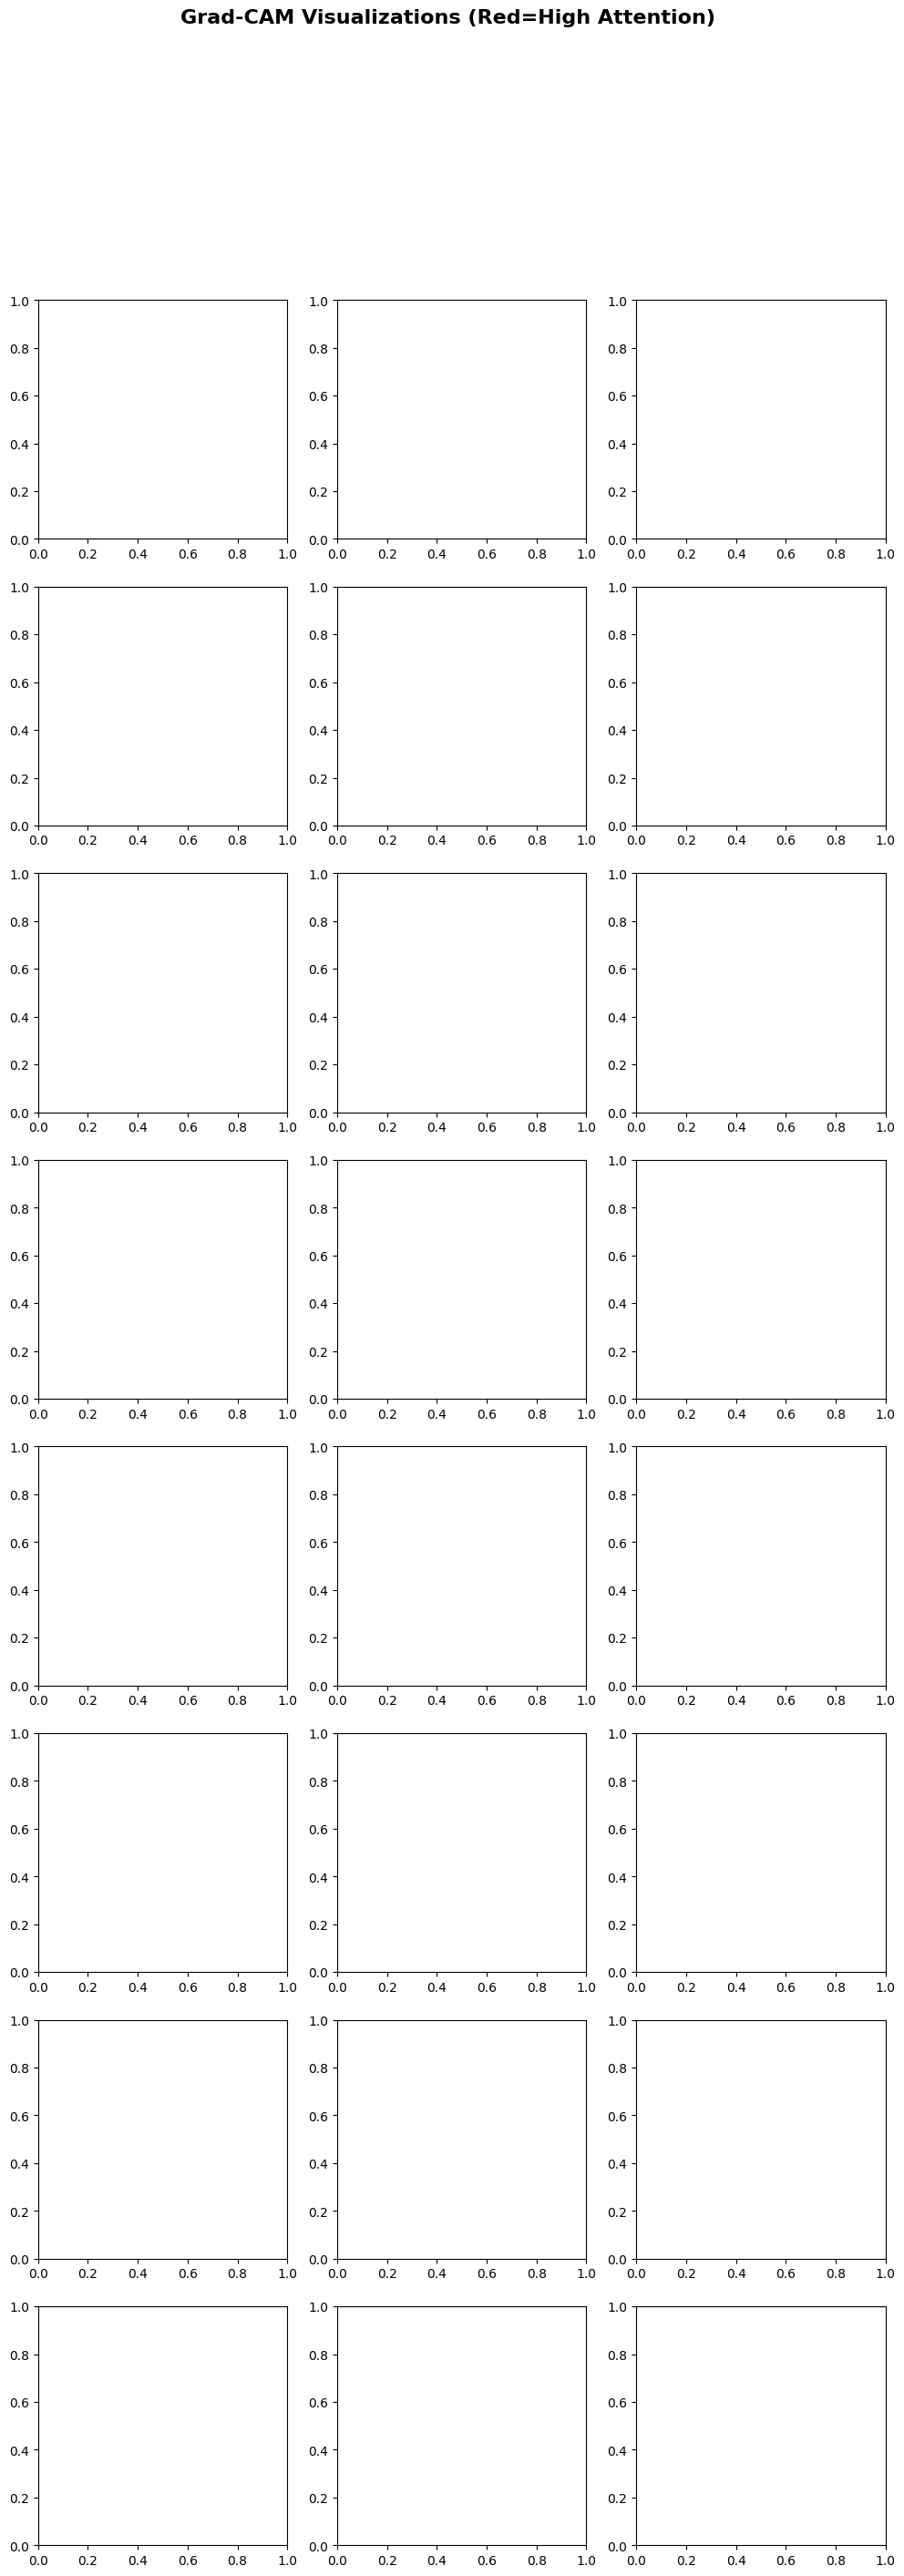

In [1]:
import os
import re
import copy
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from collections import defaultdict
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from torch.amp import GradScaler, autocast


class Config:
    SEED = 42
    DATA_DIR = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray"
    BATCH_SIZE = 32
    NUM_EPOCHS = 100  # Increased from 50 to 100
    IMG_SIZE = 224
    NUM_CLASSES = 2
    CLASS_NAMES = ["NORMAL", "PNEUMONIA"]
    VAL_FRACTION = 0.15

    LR_DENSEBLOCK3 = 1e-5
    LR_DENSEBLOCK4 = 5e-5
    LR_HEAD = 1e-4
    WEIGHT_DECAY = 1e-3

    EMA_DECAY = 0.999
    DISPLAY_SMOOTH_ALPHA = 0.6

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


config = Config()


def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(config.SEED)
print("Device:", config.DEVICE)


def get_transforms():
    train_tf = transforms.Compose([
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.RandomAffine(degrees=10, translate=(0.05, 0.05)),
        transforms.RandomResizedCrop(config.IMG_SIZE, scale=(0.85, 1.0)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    eval_tf = transforms.Compose([
        transforms.Resize((config.IMG_SIZE, config.IMG_SIZE)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    return train_tf, eval_tf


def extract_patient_id(filename, cls):
    fname = os.path.basename(filename)
    if cls == "PNEUMONIA":
        m = re.match(r"(person\d+)_", fname)
        return f"pneumonia_{m.group(1)}" if m else f"pneumonia_unk_{fname}"
    if cls == "NORMAL":
        m = re.match(r"NORMAL2-IM-(\d+)-", fname)
        if m:
            return f"normal2_{m.group(1)}"
        m = re.match(r"IM-(\d+)-", fname)
        if m:
            return f"normal_{m.group(1)}"
        return f"normal_unk_{fname}"
    return f"unk_{fname}"


def collect_files(base_dir, split, classes=("NORMAL", "PNEUMONIA")):
    items = []
    for label_idx, cls in enumerate(classes):
        folder = os.path.join(base_dir, split, cls)
        if not os.path.isdir(folder):
            continue
        for fname in sorted(os.listdir(folder)):
            if not fname.lower().endswith((".jpeg", ".jpg", ".png")):
                continue
            fpath = os.path.join(folder, fname)
            pid = f"{split}_{extract_patient_id(fname, cls)}"
            items.append((fpath, label_idx, pid))
    return items


def patient_aware_split(items, val_fraction, seed):
    rng = random.Random(seed)
    patients_by_class = defaultdict(set)
    for _, label, pid in items:
        patients_by_class[label].add(pid)

    train_pts, val_pts = set(), set()
    for label, patients in patients_by_class.items():
        patients = sorted(patients)
        rng.shuffle(patients)
        n_val = max(1, int(len(patients) * val_fraction))
        val_pts.update(patients[:n_val])
        train_pts.update(patients[n_val:])

    train_items = [it for it in items if it[2] in train_pts]
    val_items = [it for it in items if it[2] in val_pts]
    return train_items, val_items, train_pts, val_pts


class XRayDataset(Dataset):
    def __init__(self, items, transform):
        self.items = items
        self.transform = transform

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        path, label, _ = self.items[idx]
        img = Image.open(path).convert("RGB")
        return self.transform(img), label, path  # Return path for Grad-CAM


def compute_class_weights(items):
    labels = [it[1] for it in items]
    counts = np.array([labels.count(i) for i in range(config.NUM_CLASSES)], dtype=np.float32)
    weights = 1.0 / np.sqrt(counts)
    weights = weights / weights.sum() * config.NUM_CLASSES
    return torch.tensor(weights, dtype=torch.float).to(config.DEVICE)


class ModelEMA:
    def __init__(self, model, decay):
        self.module = copy.deepcopy(model).eval()
        self.decay = decay
        for p in self.module.parameters():
            p.requires_grad_(False)

    @torch.no_grad()
    def update(self, model):
        ema_sd, model_sd = self.module.state_dict(), model.state_dict()
        for k, v in model_sd.items():
            ev = ema_sd[k]
            if ev.dtype.is_floating_point:
                ev.mul_(self.decay).add_(v.detach(), alpha=1.0 - self.decay)
            else:
                ev.copy_(v)


def build_model():
    model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)

    for param in model.parameters():
        param.requires_grad = False
    for block in [model.features.denseblock3, model.features.transition3,
                  model.features.denseblock4, model.features.norm5]:
        for param in block.parameters():
            param.requires_grad = True

    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 128),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(128, config.NUM_CLASSES),
    )
    return model


def build_optimizer(model):
    block3 = list(model.features.denseblock3.parameters()) + list(model.features.transition3.parameters())
    block4 = list(model.features.denseblock4.parameters()) + list(model.features.norm5.parameters())
    head = list(model.classifier.parameters())
    return optim.AdamW([
        {"params": block3, "lr": config.LR_DENSEBLOCK3},
        {"params": block4, "lr": config.LR_DENSEBLOCK4},
        {"params": head, "lr": config.LR_HEAD},
    ], weight_decay=config.WEIGHT_DECAY)


def pick_threshold(val_labels, val_probs, min_sensitivity=0.95):
    fpr, tpr, thresholds = roc_curve(val_labels, val_probs)
    candidates = [(float(thr), float(1 - fp))
                  for tpr_val, fp, thr in zip(tpr, fpr, thresholds)
                  if tpr_val >= min_sensitivity]
    if not candidates:
        return 0.5
    return max(candidates, key=lambda x: x[1])[0]


def train_one_epoch(model, loader, criterion, optimizer, scaler, ema):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels, _ in loader:
        images = images.to(config.DEVICE, non_blocking=True)
        labels = labels.to(config.DEVICE, non_blocking=True)
        optimizer.zero_grad()
        if scaler is not None:
            with autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        ema.update(model)
        total_loss += loss.item() * images.size(0)
        correct += outputs.argmax(1).eq(labels).sum().item()
        total += labels.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_probs = [], [], []
    all_paths = []
    with torch.no_grad():
        for images, labels, paths in loader:
            images = images.to(config.DEVICE, non_blocking=True)
            labels = labels.to(config.DEVICE, non_blocking=True)
            outputs = model(images)
            total_loss += criterion(outputs, labels).item() * images.size(0)
            preds = outputs.argmax(1)
            correct += preds.eq(labels).sum().item()
            total += labels.size(0)
            probs = torch.softmax(outputs, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())
            all_paths.extend(paths)
    return total_loss / total, correct / total, all_preds, all_labels, all_probs, all_paths


def compute_metrics(labels, preds, probs):
    cm = confusion_matrix(labels, preds)
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    f1 = 2 * precision * sensitivity / (precision + sensitivity) if (precision + sensitivity) else 0.0
    fpr, tpr, _ = roc_curve(labels, probs)
    return {
        "accuracy": accuracy, "sensitivity": sensitivity, "specificity": specificity,
        "precision": precision, "f1": f1, "auc": auc(fpr, tpr),
        "youden_idx": int(np.argmax(tpr - fpr)), "confusion_matrix": cm, "fpr": fpr, "tpr": tpr,
    }


def print_results(split_name, threshold_name, threshold, labels, probs, metrics):
    print("=" * 50)
    print(f"{split_name}  {threshold_name} threshold {threshold:.4f}")
    print("=" * 50)
    for k in ["accuracy", "sensitivity", "specificity", "precision", "f1", "auc"]:
        print(f"  {k}: {metrics[k]:.4f}")
    preds = [1 if p >= threshold else 0 for p in probs]
    print(classification_report(labels, preds, target_names=config.CLASS_NAMES))


def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = tensor.cpu().numpy().transpose(1, 2, 0)
    return np.clip(std * img + mean, 0, 1)


def ema_smooth(values, alpha):
    if not values:
        return values
    out = [values[0]]
    for v in values[1:]:
        out.append(alpha * out[-1] + (1.0 - alpha) * v)
    return out


def plot_training_history(history):
    epochs = range(1, len(history["train_loss"]) + 1)
    a = config.DISPLAY_SMOOTH_ALPHA
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle("Training History", fontsize=15, fontweight="bold")
    for ax, key_train, key_val, title, ylabel in [
        (axes[0], "train_loss", "val_loss", "Loss", "Loss"),
        (axes[1], "train_acc", "val_acc", "Accuracy", "Accuracy"),
    ]:
        ax.plot(epochs, history[key_train], color="C0", alpha=0.25, linewidth=1)
        ax.plot(epochs, history[key_val], color="C1", alpha=0.25, linewidth=1, linestyle="--")
        ax.plot(epochs, ema_smooth(history[key_train], a), color="C0", linewidth=2, label="Train")
        ax.plot(epochs, ema_smooth(history[key_val], a), color="C1", linewidth=2, linestyle="--", label="Val (EMA weights)")
        ax.set_title(title)
        ax.set_xlabel("Epoch")
        ax.set_ylabel(ylabel)
        ax.legend()
        ax.grid(True, alpha=0.3)
    axes[1].set_ylim(0, 1)
    fig.text(0.5, -0.02,
             f"Solid: EMA-smoothed for display (alpha={a}). Translucent: raw per-epoch values. "
             f"Validation on EMA-averaged weights, LR via cosine annealing over {config.NUM_EPOCHS} epochs.",
             ha="center", fontsize=8, style="italic")
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_confusion_matrices(cm_def, cm_thr, sens_def, spec_def, sens_thr, spec_thr, chosen_threshold):
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("Confusion Matrices", fontsize=15, fontweight="bold")
    sns.heatmap(cm_def, annot=True, fmt="d", cmap="Blues",
                xticklabels=config.CLASS_NAMES, yticklabels=config.CLASS_NAMES, ax=axes[0])
    axes[0].set_title(f"Default 0.5\nSens: {sens_def:.3f} | Spec: {spec_def:.3f}")
    sns.heatmap(cm_thr, annot=True, fmt="d", cmap="Greens",
                xticklabels=config.CLASS_NAMES, yticklabels=config.CLASS_NAMES, ax=axes[1])
    axes[1].set_title(f"Chosen {chosen_threshold:.3f}\nSens: {sens_thr:.3f} | Spec: {spec_thr:.3f}")
    plt.tight_layout()
    plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_roc(fpr, tpr, roc_auc, chosen_threshold, youden_idx):
    plt.figure(figsize=(9, 7))
    plt.plot(fpr, tpr, color="steelblue", linewidth=2, label=f"ROC (AUC = {roc_auc:.4f})")
    plt.plot([0, 1], [0, 1], color="gray", linewidth=1, linestyle="--", label="Random")
    plt.scatter(fpr[youden_idx], tpr[youden_idx], color="red", s=120, zorder=5,
                label=f"Chosen threshold={chosen_threshold:.3f}")
    plt.fill_between(fpr, tpr, alpha=0.1, color="steelblue")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve", fontweight="bold")
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 1)
    plt.ylim(0, 1.02)
    plt.tight_layout()
    plt.savefig("roc_curve.png", dpi=150, bbox_inches="tight")
    plt.show()


def visualize_predictions(model, loader, threshold, num_samples=16):
    model.eval()
    correct_samples, wrong_samples = [], []
    with torch.no_grad():
        for images, labels, paths in loader:
            probs = torch.softmax(model(images.to(config.DEVICE)), dim=1)
            preds = (probs[:, 1] >= threshold).cpu().numpy().astype(int)
            for i in range(len(labels)):
                entry = (images[i].cpu(), int(labels[i].item()), int(preds[i]), probs[i].cpu().numpy())
                (correct_samples if entry[1] == entry[2] else wrong_samples).append(entry)
            if len(correct_samples) >= num_samples and len(wrong_samples) >= num_samples:
                break
    n_wrong = min(num_samples // 2, len(wrong_samples))
    n_right = min(num_samples - n_wrong, len(correct_samples))
    samples = correct_samples[:n_right] + wrong_samples[:n_wrong]
    cols = 4
    rows = (len(samples) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    fig.suptitle("Sample predictions (green=correct, red=wrong)", fontsize=14, fontweight="bold")
    axes_flat = axes.flat if hasattr(axes, "flat") else [axes]
    for idx, ax in enumerate(axes_flat):
        if idx >= len(samples):
            ax.axis("off")
            continue
        img, true_lbl, pred_lbl, prob = samples[idx]
        ok = true_lbl == pred_lbl
        ax.imshow(denormalize(img))
        ax.axis("off")
        for spine in ax.spines.values():
            spine.set_edgecolor("limegreen" if ok else "crimson")
            spine.set_linewidth(4)
            spine.set_visible(True)
        ax.set_title(f"True: {config.CLASS_NAMES[true_lbl]}\nPred: {config.CLASS_NAMES[pred_lbl]}\n"
                     f"P(N): {prob[0]*100:.1f}%  P(P): {prob[1]*100:.1f}%",
                     fontsize=9, color="limegreen" if ok else "crimson", pad=5)
    plt.tight_layout()
    plt.savefig("sample_predictions.png", dpi=150, bbox_inches="tight")
    plt.show()


def grad_cam(model, image_tensor, target_class):
    """Generate Grad-CAM heatmap for a single image"""
    model.eval()
    image_tensor = image_tensor.unsqueeze(0).to(config.DEVICE)
    
    # Forward hook to get feature maps
    feature_maps = []
    def forward_hook(module, input, output):
        feature_maps.append(output)
    
    # Register hook on the last convolutional layer
    hook = model.features.norm5.register_forward_hook(forward_hook)
    
    # Forward pass
    outputs = model(image_tensor)
    pred_class = outputs.argmax(1).item()
    
    # Backward pass for target class
    model.zero_grad()
    one_hot = torch.zeros_like(outputs)
    one_hot[0, target_class] = 1
    outputs.backward(gradient=one_hot)
    
    # Get gradients and feature maps
    gradients = model.features.norm5.weight.grad.clone()
    feature_maps = feature_maps[0].clone()
    
    hook.remove()
    
    # Compute weights (global average pooling of gradients)
    weights = torch.mean(gradients, dim=[2, 3], keepdim=True)
    
    # Weighted combination of feature maps
    cam = torch.sum(weights * feature_maps, dim=1, keepdim=True)
    cam = torch.relu(cam)
    
    # Normalize
    cam = cam - cam.min()
    cam = cam / (cam.max() + 1e-8)
    
    return cam.squeeze().cpu().detach().numpy(), pred_class


def visualize_gradcam(model, loader, num_samples=8):
    """Visualize Grad-CAM for sample images"""
    model.eval()
    samples = []
    with torch.no_grad():
        for images, labels, paths in loader:
            for i in range(len(labels)):
                samples.append((images[i], labels[i].item(), paths[i]))
                if len(samples) >= num_samples:
                    break
            if len(samples) >= num_samples:
                break
    
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4*num_samples))
    fig.suptitle("Grad-CAM Visualizations (Red=High Attention)", fontsize=16, fontweight="bold")
    
    for idx, (img, label, path) in enumerate(samples):
        # Get Grad-CAM for both classes
        cam_normal, pred_normal = grad_cam(model, img, 0)
        cam_pneumonia, pred_pneumonia = grad_cam(model, img, 1)
        
        # Original image
        denorm_img = denormalize(img)
        
        # Grad-CAM heatmaps
        def overlay_cam(img, cam):
            cam_resized = cv2.resize(cam, (img.shape[1], img.shape[0]))
            heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
            heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0
            overlay = 0.5 * img + 0.5 * heatmap
            return np.clip(overlay, 0, 1)
        
        img_normal_cam = overlay_cam(denorm_img, cam_normal)
        img_pneumonia_cam = overlay_cam(denorm_img, cam_pneumonia)
        
        # Display
        axes[idx, 0].imshow(denorm_img)
        axes[idx, 0].set_title(f"Original\nTrue: {config.CLASS_NAMES[label]}")
        axes[idx, 0].axis('off')
        
        axes[idx, 1].imshow(img_normal_cam)
        axes[idx, 1].set_title(f"Grad-CAM NORMAL\nPred: {config.CLASS_NAMES[pred_normal]}")
        axes[idx, 1].axis('off')
        
        axes[idx, 2].imshow(img_pneumonia_cam)
        axes[idx, 2].set_title(f"Grad-CAM PNEUMONIA\nPred: {config.CLASS_NAMES[pred_pneumonia]}")
        axes[idx, 2].axis('off')
    
    plt.tight_layout()
    plt.savefig("gradcam_visualization.png", dpi=150, bbox_inches="tight")
    plt.show()


def plot_all_metrics_comparison(metrics_train, metrics_val, metrics_test):
    """Create a comprehensive comparison bar chart"""
    metrics_names = ["accuracy", "sensitivity", "specificity", "precision", "f1", "auc"]
    
    fig, ax = plt.subplots(figsize=(12, 6))
    x = np.arange(len(metrics_names))
    width = 0.25
    
    train_vals = [metrics_train[m] for m in metrics_names]
    val_vals = [metrics_val[m] for m in metrics_names]
    test_vals = [metrics_test[m] for m in metrics_names]
    
    ax.bar(x - width, train_vals, width, label='Train', color='C0', alpha=0.8)
    ax.bar(x, val_vals, width, label='Validation', color='C1', alpha=0.8)
    ax.bar(x + width, test_vals, width, label='Test', color='C2', alpha=0.8)
    
    ax.set_xlabel('Metrics')
    ax.set_ylabel('Score')
    ax.set_title('Performance Comparison: Train vs Validation vs Test')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics_names, rotation=45)
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(0, 1.05)
    
    plt.tight_layout()
    plt.savefig("metrics_comparison.png", dpi=150, bbox_inches="tight")
    plt.show()


def main():
    train_tf, eval_tf = get_transforms()

    combined = collect_files(config.DATA_DIR, "train") + collect_files(config.DATA_DIR, "val")
    train_items, val_items, train_pts, val_pts = patient_aware_split(
        combined, val_fraction=config.VAL_FRACTION, seed=config.SEED
    )
    test_items = collect_files(config.DATA_DIR, "test")
    test_pts = {it[2] for it in test_items}

    print(f"Train images: {len(train_items)}  patients: {len(train_pts)}")
    print(f"Val images:   {len(val_items)}    patients: {len(val_pts)}")
    print(f"Test images:  {len(test_items)}   patients: {len(test_pts)}")

    train_loader = DataLoader(XRayDataset(train_items, train_tf), batch_size=config.BATCH_SIZE,
                              shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(XRayDataset(val_items, eval_tf), batch_size=config.BATCH_SIZE,
                            shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(XRayDataset(test_items, eval_tf), batch_size=config.BATCH_SIZE,
                             shuffle=False, num_workers=2, pin_memory=True)

    class_weights = compute_class_weights(train_items)
    print(f"Class weights (sqrt): {class_weights.cpu().numpy()}")

    model = build_model().to(config.DEVICE)
    optimizer = build_optimizer(model)
    ema = ModelEMA(model, decay=config.EMA_DECAY)

    train_criterion = nn.CrossEntropyLoss(weight=class_weights)
    eval_criterion = nn.CrossEntropyLoss()
    scheduler = CosineAnnealingLR(optimizer, T_max=config.NUM_EPOCHS)
    scaler = GradScaler("cuda") if config.DEVICE.type == "cuda" else None

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_val_loss = float("inf")
    best_state = None

    print("Starting training (full budget, EMA weights, cosine LR)")
    for epoch in range(config.NUM_EPOCHS):
        train_loss, train_acc = train_one_epoch(model, train_loader, train_criterion, optimizer, scaler, ema)
        val_loss, val_acc, _, _, _, _ = evaluate(ema.module, val_loader, eval_criterion)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)
        lrs = [pg["lr"] for pg in optimizer.param_groups]
        print(f"Epoch {epoch+1:02d}/{config.NUM_EPOCHS}  Train L={train_loss:.4f} A={train_acc:.4f}  "
              f"Val L={val_loss:.4f} A={val_acc:.4f}  LRs={lrs[0]:.2e}/{lrs[1]:.2e}/{lrs[2]:.2e}")

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.cpu().clone() for k, v in ema.module.state_dict().items()}
            print("  best EMA model updated")

    plot_training_history(history)

    model.load_state_dict(best_state)

    # Evaluate on all datasets
    print("\n" + "="*60)
    print("FINAL EVALUATION ON ALL DATASETS")
    print("="*60)
    
    # Training set evaluation
    train_loss, train_acc, train_preds, train_labels, train_probs, _ = evaluate(model, train_loader, eval_criterion)
    print(f"\nTraining Set - Loss: {train_loss:.4f}, Accuracy: {train_acc:.4f}")
    
    # Validation set evaluation
    val_loss, val_acc, val_preds, val_labels, val_probs, _ = evaluate(model, val_loader, eval_criterion)
    print(f"Validation Set - Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")
    
    # Test set evaluation
    test_loss, test_acc, test_preds, test_labels, test_probs, test_paths = evaluate(model, test_loader, eval_criterion)
    print(f"Test Set - Loss: {test_loss:.4f}, Accuracy: {test_acc:.4f}\n")

    # Compute thresholds and metrics
    chosen_threshold = pick_threshold(val_labels, val_probs, min_sensitivity=0.95)
    print(f"Chosen threshold (>=95% sensitivity on val): {chosen_threshold:.4f}")

    # Compute metrics for all sets
    metrics_train = compute_metrics(train_labels, [1 if p >= 0.5 else 0 for p in train_probs], train_probs)
    metrics_val = compute_metrics(val_labels, [1 if p >= 0.5 else 0 for p in val_probs], val_probs)
    metrics_test_def = compute_metrics(test_labels, [1 if p >= 0.5 else 0 for p in test_probs], test_probs)
    metrics_test_thr = compute_metrics(test_labels, [1 if p >= chosen_threshold else 0 for p in test_probs], test_probs)

    # Print detailed results
    print_results("TRAIN SET", "default", 0.5, train_labels, train_probs, metrics_train)
    print_results("VALIDATION SET", "default", 0.5, val_labels, val_probs, metrics_val)
    print_results("TEST SET", "default", 0.5, test_labels, test_probs, metrics_test_def)
    print_results("TEST SET", "chosen", chosen_threshold, test_labels, test_probs, metrics_test_thr)

    # Visualizations
    plot_all_metrics_comparison(metrics_train, metrics_val, metrics_test_def)
    plot_confusion_matrices(
        metrics_test_def["confusion_matrix"], metrics_test_thr["confusion_matrix"],
        metrics_test_def["sensitivity"], metrics_test_def["specificity"],
        metrics_test_thr["sensitivity"], metrics_test_thr["specificity"], chosen_threshold,
    )
    plot_roc(metrics_test_def["fpr"], metrics_test_def["tpr"], metrics_test_def["auc"],
             chosen_threshold, metrics_test_def["youden_idx"])
    visualize_predictions(model, test_loader, chosen_threshold)
    
    # Grad-CAM Visualization
    print("\nGenerating Grad-CAM visualizations...")
    visualize_gradcam(model, test_loader, num_samples=8)

    torch.save(best_state, "best_model_densenet121_v3_ema.pth")
    print("Saved best_model_densenet121_v3_ema.pth")


if __name__ == "__main__":
    main()